<div style="text-align:center">
<h1>Section 8: Analysing Raster Data (Part I)</h1>
<h2>5SSG2060 Principles of Spatial Data Science</h2>
</div>

## Contents

0. <a href=#section0>Intro and Setup</a>
1. <a href=#section1>Raster: Initial Wrangling</a>
2. <a href=#section2>Cropping Rasters</a>
3. <a href=#section3>Reclassifying Categorical Rasters</a>
4. <a href=#section4>Analysing Aggregate Change</a>
5. <a href=#section5>Plotting Categorical Rasters</a>


<a name="section0"></a>
## 0. Intro and Setup

In Sections 8 and 9, we will learn about analysing raster data, specifically categorical land cover maps. 

We will use GB Land Cover data from the UKCEH [Land Cover Map products](https://www.ceh.ac.uk/data/ukceh-land-cover-maps). This week we will conduct analyses similar to those presented by Clare Rowland of [UKCEH](https://www.ceh.ac.uk/) in her [ialeUK Landscape Connections](https://iale.uk/landscape-connections) talk [from 8:34](https://youtu.be/NZZvE6OH9bI?t=514) to examine change over time and to create spatial maps of the data.  

<img src="https://www.ceh.ac.uk/sites/default/files/Land%20Cover%20Change-GB-rgb.jpg" width="400px"></img>

By the end of this practical you should:
- have practiced reading and writing raster data, and learned how to do simple spatial manipulations such as cropping
- understand how to convert raster data held as a `numpy` array to a `Pandas` DataFrame to enable plotting using methods learned previously (e.g. Week 8 of Foundations of SDS)
- understand the basics of plotting raster data spatially, particularly for categorical data. 

In Section 9 we will focus more on spatial analysis of raster data. 

**Note**: Please save the datasets and notebooks for Section 8 and 9 in the same directory to easy data access.

It's good practice to import all the packages we require for our analysis in one place at the outset. 

In [1]:
#handle warnings
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

import rasterio as rio
from rasterio.plot import show
import rasterio.mask

import copy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm

import pandas as pd
import geopandas as gpd
import numpy as np

In [Clare Rowland's talk]((https://youtu.be/NZZvE6OH9bI?t=514)), she presents results from the [Land Cover Change 1990-2015 product](https://www.ceh.ac.uk/services/land-cover-change-1990-2015). That product uses a raster data data structure, as is common for land use/cover data. Those data are [provided](https://catalogue.ceh.ac.uk/documents/fe69e8bb-5fe6-43be-8681-baa54df1399a) at 25m resolution, resulting in a file 7.5GB in size. Such a large data product is unwieldy for the learning activities in these two weeks, so we will instead work with data at 1km resolution. 

The data that we read and work with here are wrangled from the 1km data downloaded from the [UK CEH LCM repository](https://catalogue.ceh.ac.uk/documents/c0078881-7d5a-4641-91e2-c271426bc8a1) raster and ONS Geography vector, namely:

- Land Cover Map 1990 - 1km dominant target class, GB v2 (Rowland _et al._ 2020)
- Land Cover Map 2000 - 1km dominant target class, GB (Fuller _et al._ 2002)
- Land Cover Map 2015 - 1km dominant target class, GB (Rowland _et al._ 2017)
- Digital vector boundaries for Counties and Unitary Authorities in the UK (ONS Geography 2019)


<a name="section1"></a>
## 1. Raster: Initial Wrangling

The original raster data downloaded from UKCEH were inconsistent in attributes, requiring metadata information check and further transforming into new `.tif` files. 

We can use the `open` [function](https://rasterio.readthedocs.io/en/latest/api/rasterio.html#rasterio.open) from **Rasterio** directly to create `DatasetReader` objects to check the metadata:

In [2]:
lcm1990 = rio.open("data/1990/data/gb1990lcm1km_dominant.tif")
lcm2000 = rio.open("data/2000/data/LCM2000_GB_1K_DOM_TAR.tif")
lcm2015 = rio.open("data/2015/data/lcm2015_gb_1km_dominant_target_class.img")

**Note**: These are `DatasetReader` objects (you could check it out by using `"print (type())"`) and we haven't actually read the data into memory yet. It helps us to access information about the raster data before reading the very large data files into memory (taking up computer resources we might need for other data). See the attributes of `DatasetReader` objects [here](https://rasterio.readthedocs.io/en/latest/api/rasterio.io.html#rasterio.io.DatasetReader).

For example, we can access the metadata of the raster file using the `meta` method on the `DatasetReader` object: 

In [3]:
lcm1990.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': None,
 'width': 700,
 'height': 1300,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["OSGB36 / British National Grid",GEOGCS["OSGB36",DATUM["Ordnance_Survey_of_Great_Britain_1936",SPHEROID["Airy 1830",6377563.396,299.3249646,AUTHORITY["EPSG","7001"]],AUTHORITY["EPSG","6277"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4277"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-2],PARAMETER["scale_factor",0.9996012717],PARAMETER["false_easting",400000],PARAMETER["false_northing",-100000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","27700"]]'),
 'transform': Affine(1000.0, 0.0, 0.0,
        0.0, -1000.0, 1300000.0)}

### TASK

Write code to view the metadata for _lcm2000_ and _lcm2015_.

In [4]:
# meta data for lcm2000!
lcm2000.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': 255.0,
 'width': 700,
 'height': 1300,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["OSGB36 / British National Grid",GEOGCS["OSGB36",DATUM["Ordnance_Survey_of_Great_Britain_1936",SPHEROID["Airy 1830",6377563.396,299.3249646,AUTHORITY["EPSG","7001"]],AUTHORITY["EPSG","6277"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-2],PARAMETER["scale_factor",0.9996012717],PARAMETER["false_easting",400000],PARAMETER["false_northing",-100000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 'transform': Affine(1000.0, 0.0, 0.0,
        0.0, -1000.0, 1300000.0)}

In [5]:
# meta data for lcm2015!
lcm2015.meta

{'driver': 'HFA',
 'dtype': 'uint8',
 'nodata': None,
 'width': 700,
 'height': 1300,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["Transverse Mercator",GEOGCS["Ord. Survey G. Britain 1936",DATUM["Ord. Survey G. Britain 1936",SPHEROID["Airy",6377563.396,299.324975315035],TOWGS84[375,-111,431,0,0,0,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-2],PARAMETER["scale_factor",0.9996012717],PARAMETER["false_easting",400000],PARAMETER["false_northing",-100000],UNIT["meters",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 'transform': Affine(1000.0, 0.0, 0.0,
        0.0, -1000.0, 1300000.0)}

The `meta` attribute is a dictionary containing the basic metadata of the dataset. It contains information on:
- driver: the file format ([using](https://rasterio.readthedocs.io/en/latest/api/rasterio.drivers.html) GDAL standard); examples include GeoTiff and NetCDF
- dtype: the data type(s) of band(s) in the dataset (in index order); examples include int and float
- nodata: the value used to indicate pixels that do not contain valid data
- width: the number of pixels in the horizontal
- height: the number of pixels in the vertial
- count: the number of bands in the dataset
- crs: the coordinate reference system (i.e. the definition of the real-world system in which a raster’s pixels are located)
- transform: the parameters by which pixel coordinates (in the data grid) are transformed into coordinates in the CRS (see more [here](https://rasterio.readthedocs.io/en/latest/topics/georeferencing.html))

From the outputs checking metadata for all 3 observation years, we can find the datasets are very similar but not identical, with differences in:
1. `driver`: The 2015 file is in Erdas Imagine (`.img`) format, which the reader recognises. Once the data are read, this shouldn't make a difference. 
2. `nodata`: I believe all of these are incorrect as additional metadata online suggests the `nodata` value is likely zero (as it is not included in the classification table) and the 255 is likely from RGB bands (pre-classification)
3. `CRS`: `from_epsg: 6312` in the 2015 dataset, `from_epsg: 27700` in the 1990 and 2000 datasets).

To make all three datafiles consistent, we can use the `update` method on the `profile` attribute to rewrite the datafiles into disk. 

In [6]:
out_profile = lcm2015.profile
out_profile.update({"nodata": 0,
                    "crs": lcm1990.crs})

#https://rasterio.readthedocs.io/en/latest/topics/writing.html
#note if lcm2015-BNG.tif already exists, this will fail (delete the file from disk first)
with rio.Env():
    with rio.open('data/lcm2015-BNG.tif', 'w', **out_profile) as dst:  
        dst.write(lcm2015.read(1),1) 

In [7]:
out_profile = lcm2000.profile
out_profile.update({"nodata": 0})

#note if lcm2015-BNG.tif already exists, this will fail (delete the file from disk first)
with rio.Env():
    with rio.open('data/lcm2000-BNG.tif', 'w', **out_profile) as dst:
        dst.write(lcm2000.read(1),1) 

In [8]:
out_profile = lcm1990.profile
out_profile.update({"nodata": 0})

#note if lcm2015-BNG.tif already exists, this will fail (delete the file from disk first)
with rio.Env():
    with rio.open('data/lcm1990-BNG.tif', 'w', **out_profile) as dst:
        dst.write(lcm1990.read(1),1) 

Read the consistent files back in from disk: 

In [9]:
lcm1990_new = rio.open("data/lcm1990-BNG.tif")
lcm2000_new = rio.open("data/lcm2000-BNG.tif")
lcm2015_new = rio.open("data/lcm2015-BNG.tif")

And plot to check:

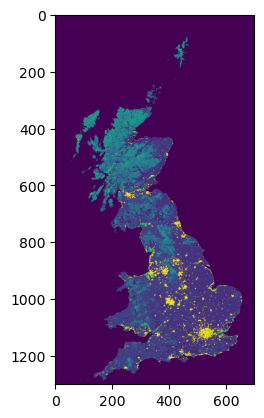

<Axes: >

In [10]:
lcm1990_newr = lcm1990_new.read(1)                       #2d numpy ndarray
show(lcm1990_newr, cmap='viridis')                       #using the rasterio show function

<a name="section2"></a>
## 2. Cropping Rasters

### 2.1 Vector Boundary Data

Rather than work with data for the entire UK, we will focus only on Wales 
The vector data will be used as boundaries are from [ONS Geography](https://www.data.gov.uk/dataset/a4709912-f26b-43a5-a3e5-c858d712607a/countries-december-2022-boundaries-gb-buc) (2022)

In [11]:
lads = gpd.read_file("data/Countries_(December_2022)_GB_BUC.geojson").set_index('FID')
lads.head()

,CTRY22CD,CTRY22NM,CTRY22NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,SHAPE_Length,SHAPE_Area,geometry
FID,,,,,,,,,,,
1,E92000001,England,Lloegr,394883,370883,-2.07811,53.234970,{57FD41D4-E324-4FFD-9C8D-5E1D8BABEF68},61.013272,17.332921,"MULTIPOLYGON (((-6.34905 49.89822, -6.32842 49..."
2,S92000003,Scotland,Yr Alban,277744,700060,-3.97094,56.177429,{E6A9DD70-6152-4619-B69F-FE4059D2CBB7},130.644877,11.569044,"MULTIPOLYGON (((-3.06034 54.98452, -3.06335 54..."
3,W92000004,Wales,Cymru,263405,242881,-3.99417,52.067410,{31F21FA3-C692-4025-8DE9-82641EA2333F},21.209862,2.742505,"MULTIPOLYGON (((-4.33394 51.56503, -4.31132 51..."


The `geometry` column exhibits very familiar latitude and longitude coordinates, which is [EPSG for WGS84](https://epsg.io/4326), _but_

> The coordinate reference system for all GeoJSON coordinates is a geographic coordinate reference system, using the [World Geodetic System 1984 (WGS 84) datum](https://epsg.io/4326), with longitude and latitude units of decimal degrees. [[source]](https://datatracker.ietf.org/doc/html/rfc7946#page-12)

We can check the stored CRS by calling $crs$ function:

In [12]:
print(lads.crs)

EPSG:4326


Since it is unprojected, we have to re-project the vector data to be align with the raster data which use the [OSGB 1936 / British National Grid](https://en.wikipedia.org/wiki/Ordnance_Survey_National_Grid), with EPSG code of OSGB 1936 at `27700`. You can find ESPG codes for different CRS by [searching epsg.io](https://epsg.io).

In [13]:
lads_reproj  = lads.to_crs({'init': 'epsg:27700'})

Then ready to save the boundary for Wales onto disk for next operation.

In [14]:
lads_reproj_wales=lads_reproj[lads_reproj['CTRY22NM']=='Wales']

In [15]:
lads_reproj_wales.to_file("data/WalesBoundary.geojson", driver='GeoJSON')

### 2.2 Crop Raster Data
From the [EarthLab cropping tutorial](https://www.earthdatascience.org/workshops/gis-open-source-python/crop-raster-data-in-python/):

> _What Does Crop a Raster Mean?_
>
>Cropping (sometimes also referred to as clipping), is when you subset or make a dataset smaller, by removing all data outside of the crop area or spatial extent. ...
This is useful as it:
>
>- Makes the data smaller and
>- Makes processing and plotting faster
>
>In general when you can, it’s often a good idea to crop your raster data!

We'll do our crop using the `rasterio mask` [function](https://rasterio.readthedocs.io/en/latest/api/rasterio.mask.html?highlight=mask#rasterio.mask.mask). To use the function, at a minimum we need to to pass it:
1. the raster `dataset` we want to crop (as a `DatasetReader` object)
2. the vector `shapes` that define the extent we want to crop to (here this is the `geometry` column of our GeoDataFrame)
3. indicate `crop=True`

Let's take the data for 2015 as an example, and you are expected to crop the data for 1990 and 2000 on your own.

In [16]:
lcm2015_wales, lcm2015_wales_transform = rasterio.mask.mask(dataset=lcm2015_new, 
                                                            shapes=lads_reproj_wales.geometry, 
                                                            crop=True)

*Note*: the `rasterio mask` function returns two elements (potentially as a tuple):
1. a `ndarray` for data contained in the raster after applying the mask
2. a `Affine` object (also known as the `transform`) that contains information for mapping pixel coordinates in our masked raster to another coordinate system (like CRS data).  

We can check the `type` and `shape` our our new, masked, raster data: 

In [17]:
print(type(lcm2015_wales))

<class 'numpy.ndarray'>


In [18]:
lcm2015_wales.shape

(1, 231, 210)

### TASK

Crop *lcm1990_new* and *lcm2000_new* to the extent of Wales, creating two new rasters: *lcm1990_wales* and *lcm2015_wales*

Print them using `rasterio  show` to check the crop has worked correctly.

In [19]:
#crop
lcm1990_wales, lcm1990_wales_transform = rasterio.mask.mask(dataset=lcm1990_new, 
                                                            shapes=lads_reproj_wales.geometry, 
                                                            crop=True)

In [20]:
#check shape
lcm1990_wales.shape

(1, 231, 210)

In [21]:
#crop
lcm2000_wales, lcm2000_wales_transform = rasterio.mask.mask(dataset=lcm2000_new, 
                                                            shapes=lads_reproj_wales.geometry, 
                                                            crop=True)

In [22]:
#check shape
lcm2000_wales.shape

(1, 231, 210)

The `ndarray` we have created is still 3D, but now it seems to have fewer pixels in the 2D (231 vs 1300 and 210 vs 700 previously). Let's plot to visualise the new raster:  

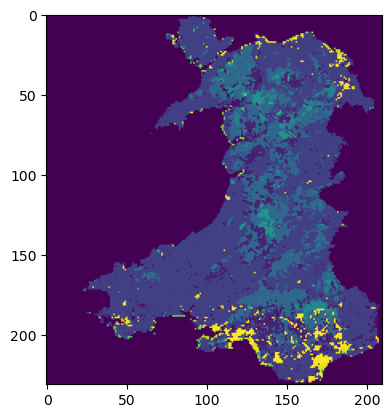

<Axes: >

In [23]:
show(lcm2015_wales[0], cmap='viridis')

### TASK

plot 2000 and 1990

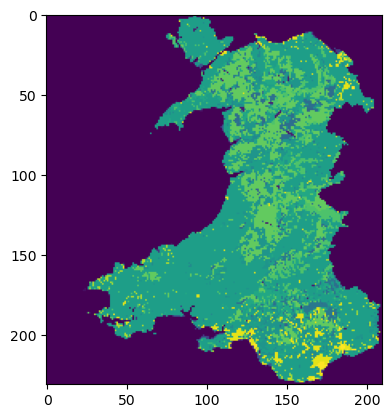

<Axes: >

In [24]:
show(lcm2000_wales[0], cmap='viridis')

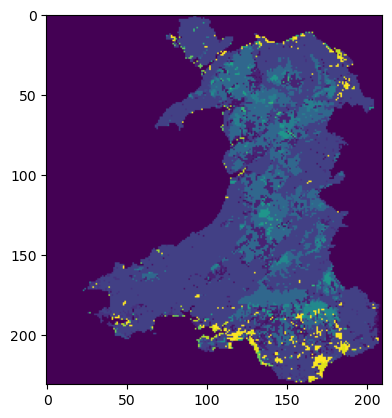

<Axes: >

In [25]:
show(lcm1990_wales[0], cmap='viridis')

It isn't vital we understand the contents of the `transform` data now, but note how this is similar to the `transform` attribute in the original data we read at the beginning:

In [26]:
lcm2015_wales_transform

Affine(1000.0, 0.0, 146000.0,
       0.0, -1000.0, 396000.0)

### 2.3 Write Cropped Raster to File

As we have created new data, it might be useful to write this to a file on disk in case we want to share it with other or use it again in future (without needing to do all the manipulation again). An example of writing to file is shown in the [rasterio instructions on masking](https://rasterio.readthedocs.io/en/latest/topics/masking-by-shapefile.html). We will adapt these slightly to write our own function to write our cropped raster:

In [27]:
#function to write ndarray to file as a .tif (with CRS etc)
def write_nd_to_tif(nd, meta, transform, filename):
    
    #update meta from original to new data extent and transform 
    meta.update({"driver": "GTiff",
                 "height": nd.shape[1],
                 "width": nd.shape[2],
                 "transform": transform})

    with rasterio.open(filename, "w", **meta) as dest:
        dest.write(nd)

In [28]:
# write to file now       
write_nd_to_tif(nd=lcm2015_wales, 
                meta=lcm2015_new.meta, 
                transform=lcm2015_wales_transform, 
                filename="data/lcm2015_wales.tif")

### TASK
Use the `write_nd_to_tif` function to write 1990 and 2000 rasters for Wales as _.tif_ onto disk.

In [29]:
#write 1990 to tif using write_nd_to_tif function
write_nd_to_tif(lcm1990_wales, 
                meta=lcm1990_new.meta, 
                transform=lcm1990_wales_transform,
                filename="data/lcm1990_wales.tif")

In [30]:
#write 2000 to tif using write_nd_to_tif function
write_nd_to_tif(lcm2000_wales, lcm2000_new.meta, lcm2000_wales_transform, "data/lcm2000_wales.tif")

<a name="section3"></a>
## 3. Reclassifying Categorical Rasters

### 3.1 Check current classification
The [Land Cover Change 1990-2015 25m product](https://www.ceh.ac.uk/services/land-cover-change-1990-2015) represents the land surface using only six classes. Other Land Cover Map products produced by UKCEH have many more classes, but for the change product the maps were re-classified to have fewer classes. 

For example, let's quickly identify the unique values in our land cover maps and how many times they are observed (i.e. how many pixels fall in each land cover class). Because are data are `numpy` objects (i.e. `ndarray`'s) we can use `numpy`'s `.unique` [function](https://numpy.org/doc/stable/reference/generated/numpy.unique.html) to [count the occurrence of each value](https://stackoverflow.com/a/28663910).

First, read the data (that we just wrote to disk) as a `numpy` `ndarray`:

In [31]:
lcm1990_wales = rio.open('data/lcm1990_wales.tif')

lcm1990_wales_np = lcm1990_wales.read(1)

Then get the unique values and counts and combine them into a dict for easier viewing:

In [32]:
unique, counts = np.unique(lcm1990_wales_np, return_counts=True)  
counts1990 = dict(zip(unique, counts))                         

And then print: 

In [33]:
print(counts1990)

{0: 27786, 1: 572, 2: 1200, 3: 378, 4: 12206, 5: 152, 7: 4379, 8: 26, 9: 432, 10: 303, 11: 166, 12: 67, 13: 24, 14: 43, 15: 2, 16: 62, 18: 46, 19: 58, 20: 117, 21: 491}


### TASK

Using the code above as a guide, print the counts of the unique values in the rasters for Wales in 2000 and 2015 (read the data from the file we just wrote to disk) 

In [34]:
#read data
lcm2000_wales = rio.open('data/lcm2000_wales.tif')
lcm2015_wales = rio.open('data/lcm2015_wales.tif')

lcm2000_wales_np = lcm2000_wales.read(1)
lcm2015_wales_np = lcm2015_wales.read(1)

unique, counts = np.unique(lcm2000_wales_np, return_counts=True)
counts2000 = dict(zip(unique, counts))

unique, counts = np.unique(lcm2015_wales_np, return_counts=True)
counts2015 = dict(zip(unique, counts))

print(counts2000)
print('\n')   #print a newline to separate the output
print(counts2015)

{0: 27716, 1: 109, 2: 59, 4: 91, 5: 29, 7: 35, 8: 34, 9: 407, 10: 307, 12: 528, 13: 1435, 14: 11048, 15: 1197, 17: 104, 18: 964, 19: 3518, 20: 6, 21: 54, 22: 205, 24: 576, 25: 88}


{0: 27716, 1: 594, 2: 1453, 3: 468, 4: 12009, 5: 60, 6: 1, 7: 4289, 8: 27, 9: 376, 10: 184, 11: 239, 12: 35, 13: 15, 14: 50, 15: 7, 16: 70, 17: 1, 18: 53, 19: 59, 20: 136, 21: 668}


What do you notice about the pixel counts for the different values (which represent distinct land cover classes)?

Hopefully you can see that the frequency of pixels with a value of `0` is the largest by far (e.g. for 2015 there are 27716 `0`'s). If we check the metadata, we can see that `0` indicates `No Data`. 

In [35]:
lcm2015_wales.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': 0.0,
 'width': 210,
 'height': 231,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["OSGB36 / British National Grid",GEOGCS["OSGB36",DATUM["Ordnance_Survey_of_Great_Britain_1936",SPHEROID["Airy 1830",6377563.396,299.3249646,AUTHORITY["EPSG","7001"]],AUTHORITY["EPSG","6277"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4277"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-2],PARAMETER["scale_factor",0.9996012717],PARAMETER["false_easting",400000],PARAMETER["false_northing",-100000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","27700"]]'),
 'transform': Affine(1000.0, 0.0, 146000.0,
        0.0, -1000.0, 396000.0)}

We can also see from our pixel counts that for 1990 and 2015 the next highest count (after `0`) is for class `4` and there are 21 classes overall. But for 2000 the next highest count (after `0`) is for class `14` and there are 25 classes. Clearly there are different classifications between the years. 

To be able to compare the years, need to make a consistent classification across the years. We will do this by aggregating the >20 classes to six broad classes in our newly defined classification through the process of **reclassification**.  

Reclassification is quite common when working with land cover data. 

<img src="https://www.landscapemodelling.net/gif/reclass-raster-esri.gif" width="400px"></img>

As EarthLab [explain](https://www.earthdatascience.org/courses/use-data-open-source-python/intro-raster-data-python/raster-data-processing/classify-plot-raster-data-in-python/), 

> When you reclassify a raster, you create a new raster. In that raster, each cell from the old raster is mapped to the new raster. The values in the new raster are applied using a defined range of values or a raster map. For example above you can see that all cells that contains the values 1-3 are assigned the new value of 5. 

We will re-classify our 1km data for to the same classes as used in the 1990-2015 25m product. This will enable us to more closely reproduce the result presented by Clare Rowland (see top). 

But first, we'll see the proof-of-concept of how to do with with `ndarray` in python. 

### 3.2 Proof of Re-classification Concept

To see how re-classification works, we'll generate a small 2D `ndarray` to work with:

In [36]:
original = np.ndarray(shape=(5,5), buffer=np.arange(25), dtype=int)
print(original)

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]


We need to create a ([deep](https://www.geeksforgeeks.org/copy-python-deep-copy-shallow-copy/)) copy of the `ndarray` to hold the new values after re-classification (remember when we reclassify a raster, we create a new raster): 

In [37]:
modified = copy.deepcopy(original)
print(modified)

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]


Next, we need to define the re-classification rules. That is, we need to specify what values should change _from_ and _to_. A `dict` will be a useful structure to do this, as we can use the `key`s as the _from_ (old) value and the `value`s as the _to_ (new) value. 

For example, let's say we want to change values in our `ndarray` as shown in the table below, with all other values remaining the same:

| old | new |
| --- | --- |
| 5   | -1  |
| 11  | -3  |
| 17  | -2  |
| 23  | -4  |

Our `dict` to do this would look like the following:

In [38]:
changes = {5: -1, 11: -3, 17: -2, 23:-4}

Now we can loop over this `dict` using the `key` to identify _old_ values in the `ndarray` to change to _new_: 

In [39]:
for old, new in changes.items(): 
    modified[original==old]=new
# Printing out two raster for comparison
print(original)
print('\n')
print(modified)

[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]


[[ 0  1  2  3  4]
 [-1  6  7  8  9]
 [10 -3 12 13 14]
 [15 16 -2 18 19]
 [20 21 22 -4 24]]


It works! We are going to use it for our LCM datasets.

### 3.3 Re-classification for Wales

We re-classify data for 1990 and 2015 first, then do 2000 later (as they will require a different re-classification scheme). 

First, we create copies of the input raster maps (but only the single 2D layer!):

In [40]:
lcm2015_wales6 = copy.deepcopy(lcm2015_wales_np)
lcm1990_wales6 = copy.deepcopy(lcm1990_wales_np)

print(lcm2015_wales6.shape)
print(lcm1990_wales6.shape)

(231, 210)
(231, 210)


Now we need to define our reclassification dictionary. The reclassification we will use is shown in Table 3 of the [Supporting Documentation](https://doi.org/10.5285/07b6e5e9-b766-48e5-a28c-5b3e35abecc0) for Rowland _et al._ (2020b) as shown in the image below:

<img src="https://www.landscapemodelling.net/png/Table3_Rowland2020.png" width="500px"></img>

Thus, our six simplified classes (from the original 21) will be:
1. Woodland
2. Cropland
3. Grassland
4. Water
5. Built-up
6. Other

From the re-classification table above, our dictionary will be:

In [41]:
# reclassify from 21 to 6
lookup = {1:1,2:1,
          3:2,
          4:3,5:3,6:3,7:3,8:3,9:3,10:3,11:3,16:3,18:3,19:3,
          14:4,
          20:5,21:5,
          12:6,13:6,15:6,17:6}

In [42]:
# modify values in both land cover maps
for old, new in lookup.items(): 
    lcm2015_wales6[lcm2015_wales_np == old]=new
    lcm1990_wales6[lcm1990_wales_np == old]=new

We can check if this has been successful by examining the unique values and counts of the new raster maps.

### TASK 
Using code above as a guide, for 1990 and 2015 get the unique values and counts (from `lcm1990_wales6` and `lcm2015_wales6`), combine them into `dict`s for easier viewing, then print the `dict`s.  

In [43]:
#answer!
unique, counts = np.unique(lcm1990_wales6, return_counts=True)  
counts1990_6 = dict(zip(unique, counts))                         

unique, counts = np.unique(lcm2015_wales6, return_counts=True)
counts2015_6 = dict(zip(unique, counts))

print(counts1990_6)
print('\n')
print(counts2015_6)

{0: 27786, 1: 1772, 2: 378, 3: 17830, 4: 43, 5: 608, 6: 93}


{0: 27716, 1: 2047, 2: 468, 3: 17367, 4: 50, 5: 804, 6: 58}


You should find that for both 1990 and 2016 you have six classes, with `0` (No Data) as the most frequently represent values, followed by `3`. 

We can also plot maps of the re-classified data to check visually that the reclass has worked.  

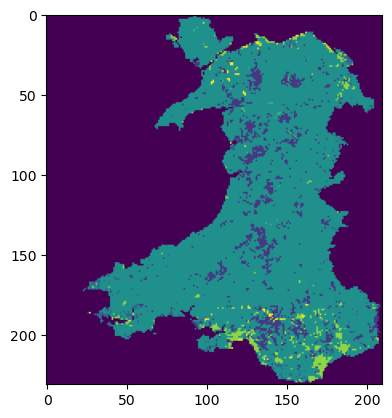

<Axes: >

In [44]:
show(lcm1990_wales6, cmap='viridis')

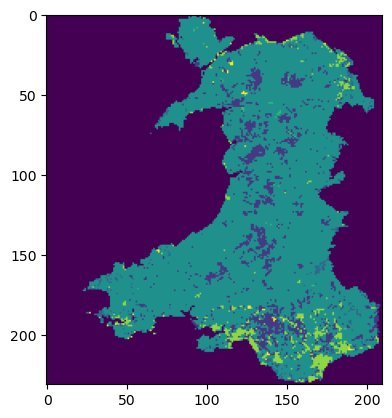

<Axes: >

In [45]:
show(lcm2015_wales6, cmap='viridis')

#### TASK

Note that the code to plot the last two maps did not include `[0]` like the maps we made above. In the box below, explain why this is. _Hint: you might want to check the shape of the reclassfied numpy arrays_

**answer!**
We don't need to use `[0]` as the reclassified numpy arrays have only two dimensions, as shown by the output of `lcm1990_wales6.shape`. Above, the data have three dimensions (it's a data cube) so we need to include `[0]` to access the first item of the third dimension.

In [46]:
##answer
lcm1990_wales6.shape

(231, 210)

For 2000 data, since it has different counts and classes, we need a different re-classification for 2000 (than for 1990 and 2015). For the reclass we should actually refer to the table in _lcm2000_raster_dataset_details.pdf_ but then otherwise we follow the same process:

In [47]:
# reclassify from 25 to 6
d2000 = {12:1,13:1,
         21:2,22:2,23:2,
         4:3,5:3,7:3,8:3,9:3,10:3,14:3,15:3,16:3,16:3,17:3,18:3,19:3,20:3,
         1:4,2:4,
         24:5,25:5,
         6:6,11:6,26:6}

# modify values in both land cover maps
lcm2000_wales6 = copy.deepcopy(lcm2000_wales_np)
for old, new in d2000.items(): 
    lcm2000_wales6[lcm2000_wales_np == old]=new


unique, counts = np.unique(lcm2000_wales6, return_counts=True)
counts2000_6 = dict(zip(unique, counts))

print(counts2000_6)

{0: 27716, 1: 1963, 2: 259, 3: 17740, 4: 168, 5: 664}


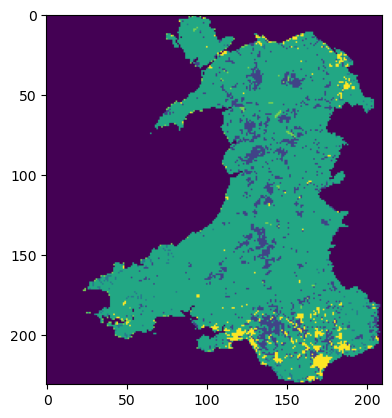

<Axes: >

In [48]:
show(lcm2000_wales6, cmap='viridis')

### 3.4 Writing reclass raster to file

As we have created new six-class rasters, it might be god to write these out to file in case we want to share them or use again without needing to re-create. 

We can use the `write_nd_to_tif` we created above, but first we need to remember that `rasterio` expects a 3D `ndarray`, whereas we have created a 2D `ndarray` when reclassifying. So first we need to 'add' the dimension we removed. We can do this using the `reshape` [function](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.reshape.html#numpy.ndarray.reshape):

In [49]:
lcm1990_wales6_out = lcm1990_wales6.reshape(1, *lcm1990_wales6.shape)  
lcm2000_wales6_out = lcm2000_wales6.reshape(1, *lcm2000_wales6.shape)  
lcm2015_wales6_out = lcm2015_wales6.reshape(1, *lcm2015_wales6.shape)  

In [50]:
write_nd_to_tif(lcm1990_wales6_out,  lcm1990_new.meta, lcm1990_wales_transform, "data/lcm1990_wales6.tif")

write_nd_to_tif(lcm2000_wales6_out,  lcm2000_new.meta, lcm2000_wales_transform, "data/lcm2000_wales6.tif")

write_nd_to_tif(lcm2015_wales6_out, lcm2015_new.meta, lcm2015_wales_transform, "data/lcm2015_wales6.tif")

<a name="section4"></a>
## 4. Analysing Aggregate Change

In this section we're going to examine land cover change across the whole of Wales for 1990-2015, using bar plot to present increases or decreases in land area for each land cover class between the two points in time. This should look something like the bar chart at the top of this notebook (and shown in the [Clare Rowland's talk at 10:50](https://youtu.be/NZZvE6OH9bI?t=650)), but without the fancy graphics and for all classes (not just four). 

Because our data are 1km resolution, each pixel represents 1 sq km. So our counts of pixels (created above) are actually also measures of land area in sq km and we can use them for our bar plot. 

But it will be easier to make a plot from these data if we convert the `dict` to a Pandas `DataFrame` (and then we can use methods like in Week 8 of the Foundations of SDS module to analyse and create plots of the data). 

We can create `DataFrame`s from `dict`s using the `from_dict` Pandas method:

In [51]:
counts_df = pd.DataFrame.from_dict(counts1990_6,orient="index") #tell pandas to use keys as indexes 
print(type(counts_df))
print(counts_df)

<class 'pandas.core.frame.DataFrame'>
       0
0  27786
1   1772
2    378
3  17830
4     43
5    608
6     93


We could do this again for the other `dict` and then `join` or `merge` the two `DataFrame`s. 

But another trick is to pass `from_dict` a list of `dict`s that share `key`s (which our `dict`s do):

In [52]:
counts_df = pd.DataFrame.from_dict([counts1990_6,counts2015_6])
print(type(counts_df))
print(counts_df)

<class 'pandas.core.frame.DataFrame'>
       0     1    2      3   4    5   6
0  27786  1772  378  17830  43  608  93
1  27716  2047  468  17367  50  804  58


Let's also create a `dict` containing labels for the land covers and add that to the `DataFrame`: 

In [53]:
lcs = ['No Data', 'Woodland', 'Cropland', 'Grassland', 'Water', 'Built-up', 'Other'] 

In [54]:
lclabs = dict(zip(np.arange(0,7).tolist(), lcs))
lclabs

{0: 'No Data',
 1: 'Woodland',
 2: 'Cropland',
 3: 'Grassland',
 4: 'Water',
 5: 'Built-up',
 6: 'Other'}

In [55]:
counts_df = pd.DataFrame.from_dict([lclabs,counts1990_6,counts2015_6])
print(type(counts_df))
print(counts_df)

<class 'pandas.core.frame.DataFrame'>
         0         1         2          3      4         5      6
0  No Data  Woodland  Cropland  Grassland  Water  Built-up  Other
1    27786      1772       378      17830     43       608     93
2    27716      2047       468      17367     50       804     58


Things will be easier for plotting if we have our table such that Land Covers are rows. To rotate a `DataFrame` we can [transpose](https://en.wikipedia.org/wiki/Transpose) the data using the `.T` pandas method:

In [56]:
counts_df = pd.DataFrame.from_dict([lclabs,counts1990_6,counts2015_6]).T
print(type(counts_df))
print(counts_df)

<class 'pandas.core.frame.DataFrame'>
           0      1      2
0    No Data  27786  27716
1   Woodland   1772   2047
2   Cropland    378    468
3  Grassland  17830  17367
4      Water     43     50
5   Built-up    608    804
6      Other     93     58


And we should re-label our columns:

In [57]:
counts_df = pd.DataFrame.from_dict([lclabs,counts1990_6,counts2015_6]).T
counts_df.columns = ['Land Cover', '1990', '2015']
counts_df

,Land Cover,1990,2015
0,No Data,27786,27716
1,Woodland,1772,2047
2,Cropland,378,468
3,Grassland,17830,17367
4,Water,43,50
5,Built-up,608,804
6,Other,93,58


Now we can simply plot using Pandas plot functionality:

<Axes: >

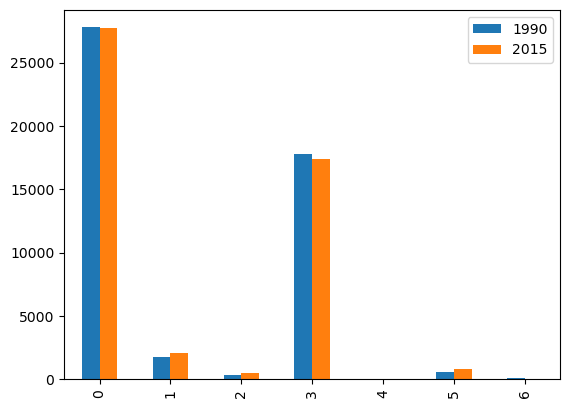

In [58]:
counts_df.plot.bar()

You should recognise this type of plot from Week 8 of Foundations of SDS. 

This plot is a good start, but we usually don't want to include 'No Data' in our plots. We can plot without 'No Data' by filtering the `DataFrame` as we plot: 

<Axes: >

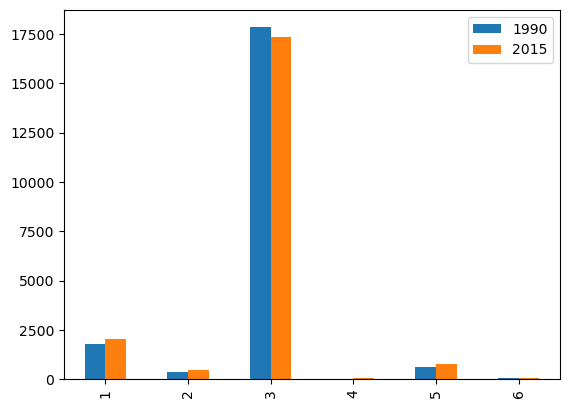

In [59]:
counts_df[counts_df['Land Cover']!='No Data'].plot.bar()

Check you understand how that code filtered out the 'No Data' class (ask a member of staff to discuss if necessary).  

We can improve the plot by:
- providing an x-axis label
- providing a y-axis label
- adding land cover classes as x-axis tick labels (rotated to improve legibility)

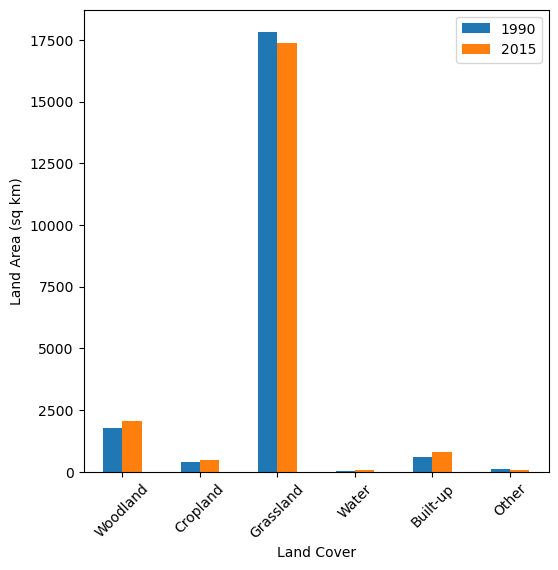

In [60]:
fig, axs = plt.subplots(1, figsize=(6,6))

counts_df[counts_df['Land Cover']!='No Data'].plot.bar(
    ax=axs, xlabel="Land Cover", ylabel='Land Area (sq km)')

axs.set_xticklabels(labels= lcs[1:], rotation=45)

plt.show()

This plot is good to see which land covers had what area for the two years. But we could create a better plot to visualise change between the two years by plotting the difference in area (something that looks more like Clare Rowland's plot at the top of this notebook). 

First we need to calculate the difference in area (i.e. number of pixels) between the two years and put the result in a new column of our `DataFrame`: 

In [61]:
counts_df['Diffc-9015'] = counts_df['2015'] - counts_df['1990']
counts_df

,Land Cover,1990,2015,Diffc-9015
0,No Data,27786,27716,-70
1,Woodland,1772,2047,275
2,Cropland,378,468,90
3,Grassland,17830,17367,-463
4,Water,43,50,7
5,Built-up,608,804,196
6,Other,93,58,-35


And now we can plot (without the 'No Data' class):

<Axes: >

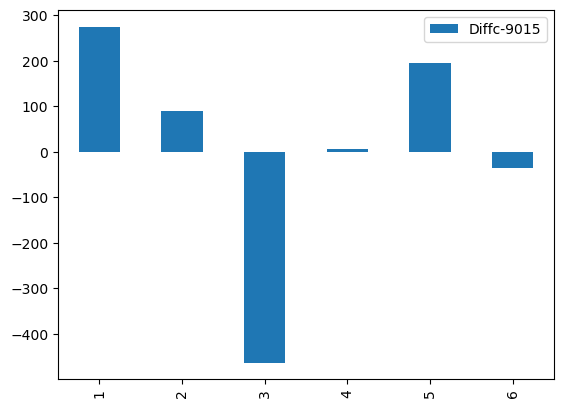

In [62]:
counts_df[counts_df['Land Cover']!='No Data'][['Diffc-9015']].plot.bar()

### TASK

Improve the plot by:
- providing an x-axis label
- providing a y-axis label
- adding land cover classes as x-axis tick labels (rotated to improve legibility)


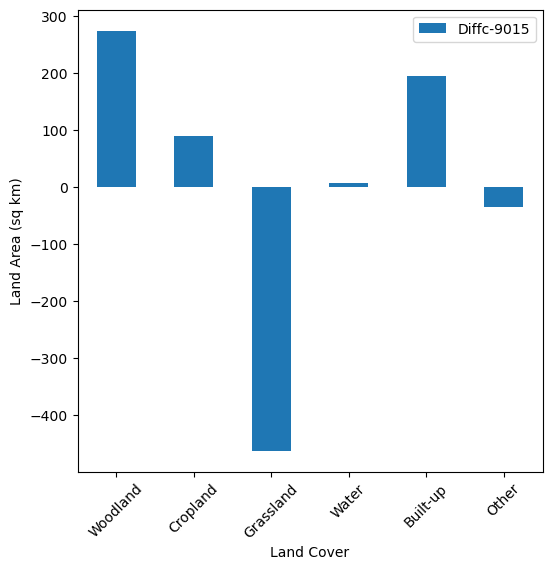

In [63]:
fig, axs = plt.subplots(1, figsize=(6,6))

counts_df[counts_df['Land Cover']!='No Data'][['Diffc-9015']].plot.bar(
    ax=axs, xlabel="Land Cover", ylabel='Land Area (sq km)')

axs.set_xticklabels(labels= lcs[1:], rotation=45)

plt.show()

Check you can see why this plot is similar to the one presented at the top of the notebook. 

### TASK
Other than the fancy graphics, how is this plot different?

In [64]:
#your answer here

#data here are for Wales only, not all GB
#cropland (arable) decreased across all of GB, but increased in Wales 

<a name="section5"></a>
## 5. Plotting Categorical Rasters

Up to this point we have quickly plotted raster maps using the `viridis` palette and not worrying too much about the visualisation. But this (continuous) colour palette isn't really appropriate for our (categorical) map. Unfortunately, matplotlib doesn't have any simple way to create categorical colour palettes, but we can combine some tools to create a nice solution. Specifically, we will use:
- `ListedColormap` [see [docs](https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.ListedColormap.html)] to set colours of pixels in the map
-  `BoundaryNorm` [see [docs](https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.BoundaryNorm.html)] to force colours in the `ListedColormap` to match the class ids we specify (in a dictionary, as suggested [here](https://stackoverflow.com/a/14779462))
- `rectangles` [see [docs](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html)] from `patches` [see [docs](https://matplotlib.org/stable/api/patches_api.html)] to create colour boxes for the legend
- present the legend with the map using `legend` [see [docs](https://matplotlib.org/stable/api/legend_api.html)]

It's useful to create a `dict` to hold the information on our land cover classes, that we will use at several points in creating the maps:
- `keys` are the class ids
- `values` are lists of a) class label and b) colour to use in the map (we could include other info the class in the list)

Note in the `dict` we use colour names that matplotlib will recognise, but there are [various other ways to define colours in matplotlib](https://matplotlib.org/stable/tutorials/colors/colors.html#sphx-glr-tutorials-colors-colors-py).

Also, note that we include _seven_ colours, as we also need to define a colour for the 'NoData' value (`0`). 

In [65]:
#define legend based on provided information
#legend mapping land cover values to class names
legend_dict = {
    0: ['No Data', 'white'],
    1: ['Woodland', 'darkgreen'],
    2: ['Cropland', 'lightyellow'],
    3: ['Grassland', 'lightgreen'],
    4: ['Water', 'blue'],
    5: ['Built-up', 'black'],
    6: ['Other', 'grey'],
}

First, we create a `ListedColourmap` (which we will pass to the `cmap` argument of the matplotlib plotting function later).

To do this we use info from the legend `dict` using a technique called _'list comprehension'_. [List comprehension](https://www.geeksforgeeks.org/python-list-comprehension/) is a way of creating a new list based on the values of an existing list using the synyax:

```python
newlist = [expression for item in oldlist]
```

We create a list of colours using list comprehension (extracting the colour name from the 1th element of the lists in the ` iit` values by iterating through a list of the `dict` keys), then convert this to a `ListedColormap`:

In [66]:
#create colormap using colours specified in the legend dict
colors = [legend_dict[key][1] for key in sorted(legend_dict.keys())]
print(colors)
lcmap = ListedColormap(colors)
print(lcmap)

['white', 'darkgreen', 'lightyellow', 'lightgreen', 'blue', 'black', 'grey']


We need to force matplotlib to match class ids to the colours specified. We do this with a `BoundaryNorm` object:  

In [67]:
#create list of ids (in the raster) from the legend keys, adding an upper bound greater than current largest
bounds = list(legend_dict.keys())
bounds.append(bounds[-1] + 1)

#create a BoundaryNorm object to scale the colormap to the legend values, e.g. https://stackoverflow.com/a/14779462
bnorm = BoundaryNorm(bounds, lcmap.N)

And now we're ready to create our maps, using the `lcmap` and `bnorm` object we created above:

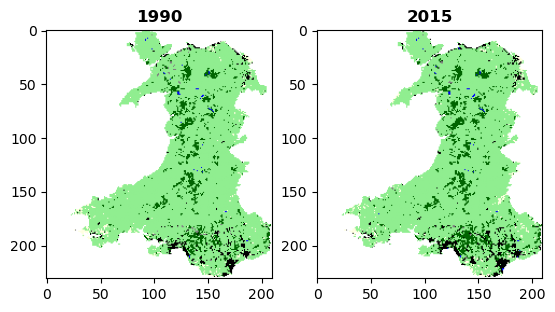

In [68]:
#create the actual plot
fig, axs = plt.subplots(1, 2)

#plot a map on each axes
show(source=lcm1990_wales6, cmap=lcmap, norm=bnorm, title="1990", ax=axs[0])
show(source=lcm2015_wales6, cmap=lcmap, norm=bnorm, title="2015", ax=axs[1])

plt.show()

Looks good! But we need to add a legend. 

The legend is composed of `rectangles` of colour (we'll call these colour boxes) with text labels to show which class each colour corresponds to. We create lists of matplotlib `rectangles` and text labels from the legend `dict` created above:  

In [69]:
#create colour boxes and labels for the map legend from the legend_dict 
colourboxes = [plt.Rectangle(xy=(0, 0),width=1,height=1, 
                         facecolor=legend_dict[key][1],edgecolor='black') for key in sorted(legend_dict.keys())]
lclabels = [f"{legend_dict[key][0]}" for key in sorted(legend_dict.keys())]

print(colourboxes)
print(lclabels)

[<matplotlib.patches.Rectangle object at 0x000002A9D5B3B620>, <matplotlib.patches.Rectangle object at 0x000002A9D5F3EA80>, <matplotlib.patches.Rectangle object at 0x000002A9D5EF6A20>, <matplotlib.patches.Rectangle object at 0x000002A9D73CB500>, <matplotlib.patches.Rectangle object at 0x000002A9D73CBB90>, <matplotlib.patches.Rectangle object at 0x000002A9D73CA900>, <matplotlib.patches.Rectangle object at 0x000002A9D73C8200>]
['No Data', 'Woodland', 'Cropland', 'Grassland', 'Water', 'Built-up', 'Other']


Now we use pass these lists to the `legend` function:

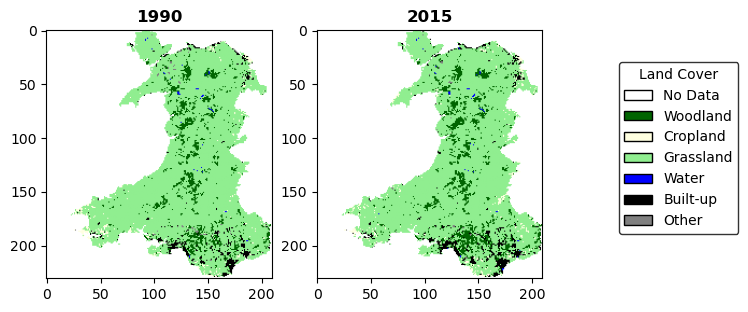

In [70]:
#create the actual plot
fig, axs = plt.subplots(1, 2)

#plot a map on each axes
show(source=lcm1990_wales6, cmap=lcmap, norm=bnorm, title="1990", ax=axs[0])
show(source=lcm2015_wales6, cmap=lcmap, norm=bnorm, title="2015", ax=axs[1])

#plot single legend (on one axes, using bbox_to_anchor to position)
legend = axs[1].legend(handles=colourboxes, 
                       labels=lclabels, 
                       bbox_to_anchor=(1.9, 0.9),
                      title="Land Cover",
                      edgecolor='black')

#print plot
plt.show()

This is looking much more appropriate for our categorical land cover data!  

Note how we plot a single legend on just one of the axes (using `bbox_to_anchor` to position - you might have to play with the coords of that object to get the legend in the right place). 

If we want to 'zoom-in' on an area of our raster, we can do this by specifying a slice of the `ndarray` (a bit like how we would slice a `list`):

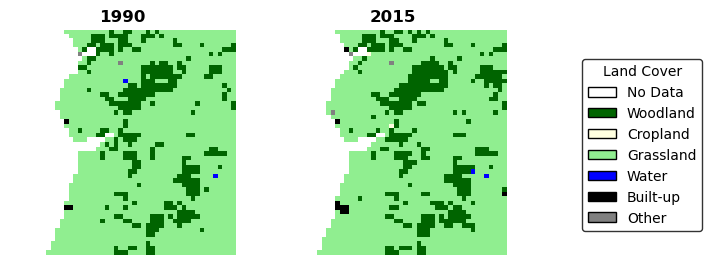

In [71]:
fig, axs = plt.subplots(1, 2)

#plot a map on each axes
show(source=lcm1990_wales6[75:125,100:150], cmap=lcmap, norm=bnorm, title="1990", ax=axs[0])
show(source=lcm2015_wales6[75:125,100:150], cmap=lcmap, norm=bnorm, title="2015", ax=axs[1])

#plot single legend (on one axes, using bbox_to_anchor to position)
legend = axs[1].legend(handles=colourboxes, 
                       labels=lclabels, 
                       bbox_to_anchor=(1.9, 0.9),
                      title="Land Cover",
                      edgecolor='black')

axs[0].set_axis_off()
axs[1].set_axis_off()

plt.show()

**Note**: this has _not_ cropped the raster data, we are just displaying a small section of the raster (the original _lcm1990_wales6_ and _lcm2015_wales6_ objects are unchanged).  

## Exercises

### Exercise 1
**Create two bar plots to show change across the three years, 1990, 2000 and 2015.**

Both should have land cover on the x-axis. One should have total land area on the y-axis for the three years. The other should have land area change for 1990-2000 and 2000-2015 (you will need to calculate these values). Format the maps so that they communicate well. Your plots should looks something like this:

<img src="https://www.landscapemodelling.net/png/Raster1-Exercise1.png" width="500px"></img>

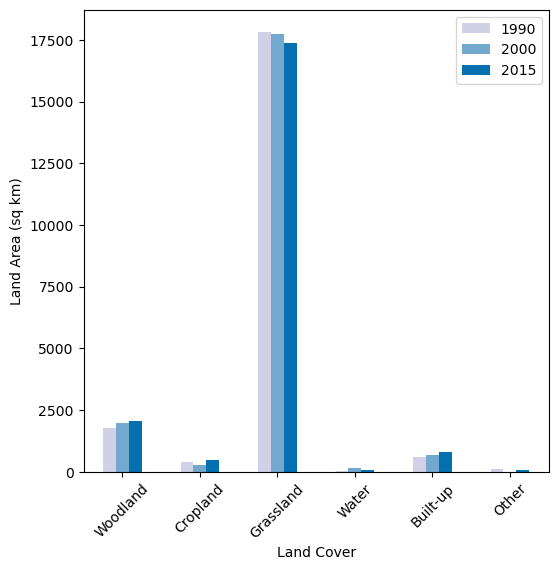

In [72]:
#first bar chart 
counts_df3 = pd.DataFrame.from_dict([lclabs,counts1990_6,counts2000_6,counts2015_6]).T
counts_df3.columns = ['Land Cover', '1990', '2000', '2015']
counts_df3

fig, axs = plt.subplots(1, figsize=(6,6))

counts_df3[counts_df3['Land Cover']!='No Data'].plot.bar(
    ax=axs, xlabel="Land Cover", ylabel='Land Area (sq km)',
    color=['#d0d1e6', '#74a9cf', '#0570b0'])

axs.set_xticklabels(labels= lcs[1:], rotation=45)

plt.show()

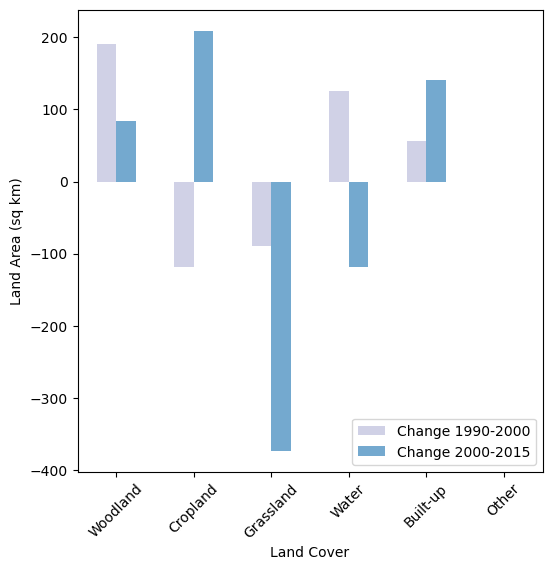

In [73]:
#second bar chart 

counts_df3['Diffc-0015'] = counts_df3['2015'] - counts_df3['2000']
counts_df3['Diffc-9000'] = counts_df3['2000'] - counts_df3['1990']

fig, axs = plt.subplots(1, figsize=(6,6))

counts_df3[counts_df3['Land Cover']!='No Data'][['Diffc-9000','Diffc-0015']].plot.bar(
    ax=axs, xlabel="Land Cover", ylabel='Land Area (sq km)',
    color=['#d0d1e6', '#74a9cf'])

axs.set_xticklabels(labels= lcs[1:], rotation=45)
axs.legend(["Change 1990-2000", "Change 2000-2015"], loc=4);

plt.show()

### Exercise 2
**Create a figure that spatially maps all three years' data with a categorical colour palette and legend.**

Your final three-year plot should look something like this:

<img src="https://www.landscapemodelling.net/png/uk-lcm-wales-exercise1.png" width="500px"></img>

Note that even though class 6 (other) is missing from the 2000 data, the approach to creating the legend with the `legend_dict` object above will still work (because we force class ids to match colours using the `BoundaryNorm` object).

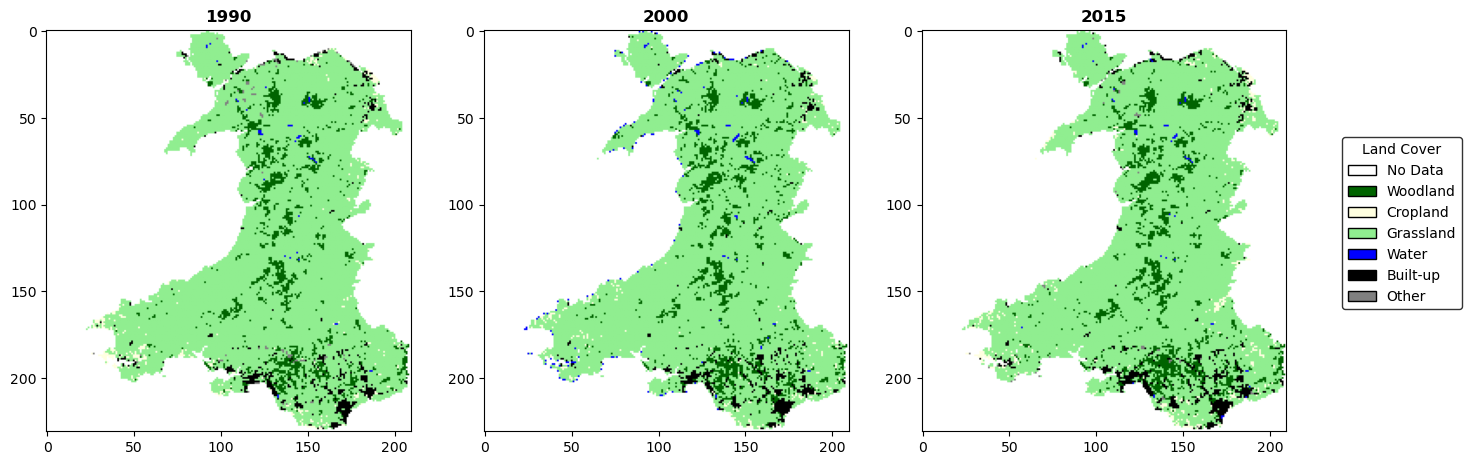

In [74]:
fig, axs = plt.subplots(1, 3, figsize=(16,6))

#plot a map on each axes
show(source=lcm1990_wales6, cmap=lcmap, norm=bnorm, title="1990", ax=axs[0])
show(source=lcm2000_wales6, cmap=lcmap, norm=bnorm, title="2000", ax=axs[1])
show(source=lcm2015_wales6, cmap=lcmap, norm=bnorm, title="2015", ax=axs[2])

#plot single legend (on one axes, using bbox_to_anchor to position)
legend = axs[2].legend(handles=colourboxes, 
                       labels=lclabels, 
                       bbox_to_anchor=(1.5, 0.75),
                      title="Land Cover",
                      edgecolor='black')
plt.show()

## References

Fuller, R.M.; Smith, G.M.; Sanderson J.M.; Hill, R.A.; Thomson, A.G.; Cox, R.; Brown, N.J.; Clarke, R.T.; Rothery, P.; Gerard, F.F. (2002). Land Cover Map 2000 (1km dominant target class, GB). _NERC Environmental Information Data Centre._ https://doi.org/10.5285/abff8409-0995-48d2-9303-468e1a9fe3df

ONS Geography (2019) Counties and Unitary Authorities (April 2019) Boundaries GB BGC. _Office for National Statistics_ https://geoportal.statistics.gov.uk/datasets/ons::counties-and-unitary-authorities-april-2019-boundaries-gb-bgc/about 

Rowland, C.S.; Morton, R.D.; Carrasco, L.; McShane, G.; O'Neil, A.W.; Wood, C.M. (2017). Land Cover Map 2015 (1km dominant target class, GB). _NERC Environmental Information Data Centre._ https://doi.org/10.5285/c4035f3d-d93e-4d63-a8f3-b00096f597f5

Rowland, C.S.; Marston, C.G.; Morton, R.D.; O’Neil, A.W. (2020a). Land Cover Map 1990 (1km dominant target class, GB) v2. _NERC Environmental Information Data Centre._ https://doi.org/10.5285/f5e3bd00-efd0-4dc6-a454-aa597d84764a

Rowland, C.S.; Marston, C.G.; Morton, R.D.; O’Neil, A.W. (2020b). Land Cover Change 1990-2015 (25m raster, GB). _NERC Environmental Information Data Centre._ https://doi.org/10.5285/07b6e5e9-b766-48e5-a28c-5b3e35abecc0

Note the licences for these data:
- [LCM licence](https://eidc.ceh.ac.uk/licences/lcm-raster/plain) (educational use only)
- [boundary data licence](https://www.ons.gov.uk/methodology/geography/licences) (Contains both Ordnance Survey and ONS Intellectual Property Rights)

## Credits!

#### Contributors:
The following individuals have contributed to these teaching materials: James Millington (james.millington@kcl.ac.uk), Yijing Li (yijing.li@kcl.ac.uk)

#### License
These teaching materials are licensed under a mix of [The MIT License](https://opensource.org/licenses/mit-license.php) and the [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 license](https://creativecommons.org/licenses/by-nc-sa/4.0/).

#### Potential Dependencies:
This notebook may depend on the following libraries: pandas, matplotlib, rasterio, matplotlib, plotly, seaborn, geopandas, numpy, sklearn, rasterstats